In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Загрузим полный набор данных

In [2]:
train_part1 = pl.scan_parquet("../ClearData_for_part_4/train_full.parquet")
# train_part1.shape

In [3]:
train_part1.schema

/tmp/ipykernel_1167/896344679.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  train_part1.schema


Schema([('event_dttm', String),
        ('event_type_nm', Int16),
        ('event_desc', Int16),
        ('channel_indicator_type', Int16),
        ('channel_indicator_sub_type', Int16),
        ('operaton_amt', Float64),
        ('currency_iso_cd', Int16),
        ('mcc_code', Int16),
        ('pos_cd', Int16),
        ('timezone', Int16),
        ('session_id', Float64),
        ('operating_system_type', Int16),
        ('battery', String),
        ('device_system_version', String),
        ('screen_size', String),
        ('developer_tools', Int16),
        ('phone_voip_call_state', Int16),
        ('web_rdp_connection', Int16),
        ('compromised', Int16),
        ('Hour', Int16),
        ('target', Int16)])

In [4]:
pos_class = train_part1.filter(pl.col("target") == 1).collect()
pos_class.shape

(51438, 21)

In [5]:
train_part1 = train_part1.filter(pl.col("target") != 1).collect()
train_part1.shape

(85626402, 21)

In [6]:
neg_class = 13_000_000
train_part1 = train_part1.sample(n=neg_class)

# columns = ["event_type_nm", "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd", "mcc_code", "pos_cd", "timezone",\
#            "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised", "operating_system_type", "event_desc"]

# for i in columns:
#     train_part1 = train_part1.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

In [7]:
train_part1 = pl.concat([train_part1, pos_class])
train_part1 = train_part1.sample(fraction=1.0, shuffle=True)
train_part1.shape

(13051438, 21)

In [8]:
train_part1 = train_part1.sort("event_dttm")
train_part1 = train_part1.drop("event_dttm")

In [9]:
x = train_part1.drop("target")
y = train_part1["target"]

In [10]:
# X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle=False)   
X_train = x[:int(0.9*len(x))]
X_test = x[int(0.9*len(x)):]
y_train = y[:int(0.9*len(y))]
y_test = y[int(0.9*len(y)):]

In [11]:
# cat_features = ["event_type_nm", "event_desc", "channel_indicator_type", "channel_indicator_sub_type", \
#                 "currency_iso_cd", "mcc_code", "pos_cd", "timezone", "operating_system_type", "battery",\
#                 "device_system_version", "screen_size", \
#                 "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised"]

# cat_features = [
#     'mcc_code', 'event_desc', 'channel_indicator_type',
#     'timezone', 'operating_system_type', 'device_system_version',
#     'screen_size', 'battery'
# ]

columns = ["event_type_nm", "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd", "mcc_code", "pos_cd", "timezone",\
           "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised", "operating_system_type", "event_desc"]

for i in columns:
    X_train = X_train.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

for i in columns:
    X_test = X_test.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery'
]

for i in cat_features:
    X_train = X_train.with_columns(pl.col(i).fill_null('missing'))

for i in cat_features:
    X_test = X_test.with_columns(pl.col(i).fill_null('missing'))

In [12]:
X_train = X_train.with_columns(pl.concat_str([pl.col("operating_system_type"), pl.col("device_system_version"), 
    pl.col("screen_size"), pl.col("battery")], separator="_").alias("device_info"))

X_test = X_test.with_columns(pl.concat_str([pl.col("operating_system_type"), pl.col("device_system_version"), 
    pl.col("screen_size"), pl.col("battery")], separator="_").alias("device_info"))

In [13]:
del train_part1, x, y
gc.collect()

0

In [14]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [15]:
cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery', 'device_info']

In [16]:
CatBoost = CatBoostClassifier(iterations=50, depth=5, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.7488352496540611
Precision: 0.010363828347132772
Recall: 0.6608817204301075
F1-score: 0.020407627941137894
PR-AUC: 0.038266813449959795

Test metrics:
Accuracy: 0.8582876678741963
Precision: 0.014880968421733436
Recall: 0.5591332523288781
F1-score: 0.02899037679089864
PR-AUC: 0.04044698443431903

Confusion matrix


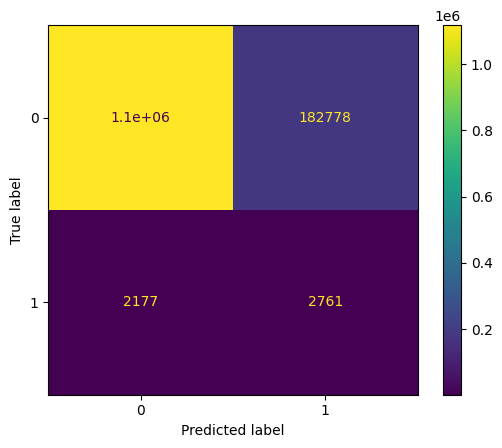

In [17]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

Попробуем настроить веса меток самостоятельно

In [18]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9412213758654432
Precision: 0.026170829304617976
Recall: 0.3824301075268817
F1-score: 0.048989183150894566
PR-AUC: 0.04013824183288289

Test metrics:
Accuracy: 0.9511011811723458
Precision: 0.02858195093832063
Recall: 0.3614823815309842
F1-score: 0.05297521887520404
PR-AUC: 0.04138261113104458

Confusion matrix


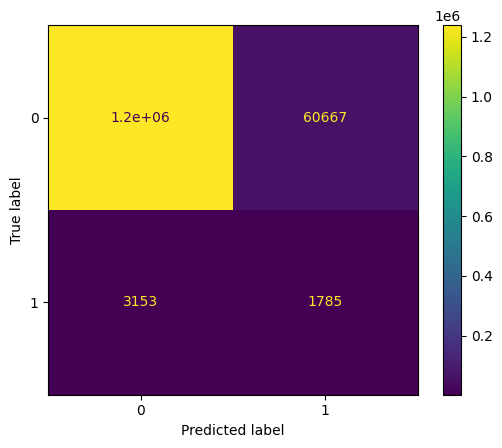

In [19]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [20]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=6, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9425705673636298
Precision: 0.027273042017464503
Recall: 0.38963440860215054
F1-score: 0.050977815730868195
PR-AUC: 0.04206742974570702

Test metrics:
Accuracy: 0.9523608122935093
Precision: 0.03006568144499179
Recall: 0.3707978938841636
F1-score: 0.055621373674777486
PR-AUC: 0.04335868651316837

Confusion matrix


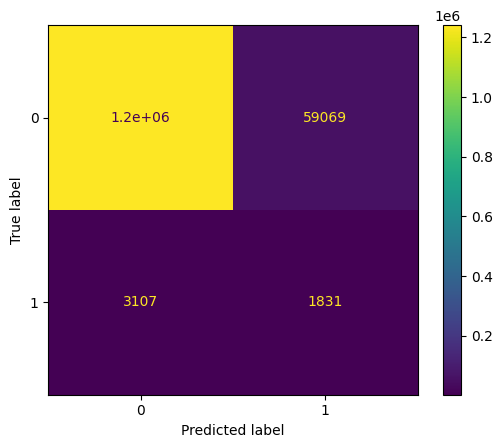

In [21]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [22]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=7, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9433317436120703
Precision: 0.02764943910745456
Recall: 0.3896989247311828
F1-score: 0.051635312957696716
PR-AUC: 0.043431206012652615

Test metrics:
Accuracy: 0.9525692184157457
Precision: 0.03044840092317837
Recall: 0.37403807209396517
F1-score: 0.05631269246013598
PR-AUC: 0.0440623980966474

Confusion matrix


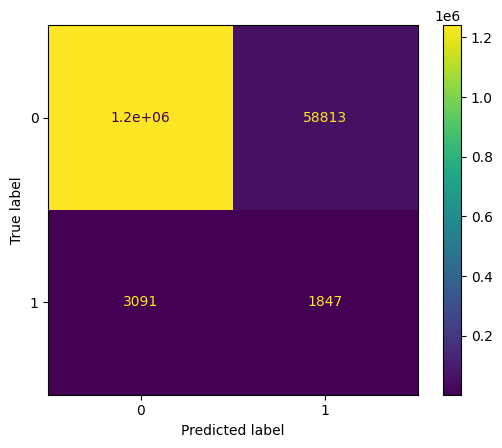

In [23]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [24]:
weights = {0: 1, 1: 500}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.44045270789237867
Precision: 0.006103450180913323
Recall: 0.8671827956989248
F1-score: 0.012121585599830459
PR-AUC: 0.036130826263321904

Test metrics:
Accuracy: 0.5031475454049514
Precision: 0.006147012597922448
Recall: 0.8110571081409478
F1-score: 0.01220154949015498
PR-AUC: 0.0391411865604965

Confusion matrix


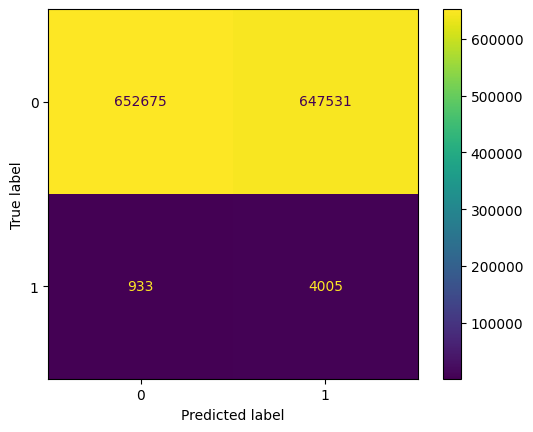

In [25]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [ ]:
cat_features = [
    'mcc_code', 'event_desc', 'channel_indicator_type',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery', 'device_info']

In [29]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=7, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9431986803667608
Precision: 0.02775330463508642
Recall: 0.39223655913978495
F1-score: 0.051838683043359014
PR-AUC: 0.043959811056894386

Test metrics:
Accuracy: 0.9517279319370123
Precision: 0.030165717244950804
Recall: 0.3774807614418793
F1-score: 0.0558669264199011
PR-AUC: 0.04403555836953639

Confusion matrix


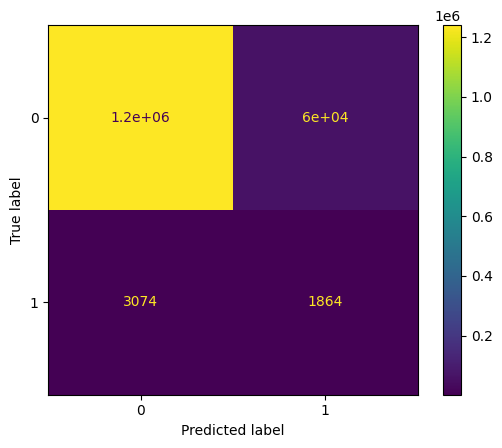

In [30]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [15]:
cat_features = ["event_type_nm", "event_desc", "channel_indicator_type", "channel_indicator_sub_type", \
                "currency_iso_cd", "mcc_code", "pos_cd", "timezone", "operating_system_type", "battery",\
                "device_system_version", "screen_size"]

In [ ]:
# one_hot_max_size=10
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, one_hot_max_size=10, cat_features=cat_features, verbose=False)

: 

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)